In [1]:
import warnings
warnings.filterwarnings("ignore")


### Cell 1: Dataset Paths

In [2]:
# ================================
# Dataset Paths
# ================================

IMAGE_FOLDER = "/kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails"

TRAIN_CSV = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv"
VAL_CSV   = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv"
TEST_CSV  = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv"

print("Paths configured.")
print(f"  Train CSV : {TRAIN_CSV}")
print(f"  Val CSV   : {VAL_CSV}")
print(f"  Test CSV  : {TEST_CSV}")
print(f"  Images    : {IMAGE_FOLDER}")


Paths configured.
  Train CSV : /kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv
  Val CSV   : /kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv
  Test CSV  : /kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv
  Images    : /kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails


### Cell 2: Text Cleaning

In [3]:
import pandas as pd
import re
import string

def remove_punctuation(text):
    if pd.isna(text): return text
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_whitespace(text):
    if pd.isna(text): return text
    return " ".join(text.split())

def remove_emojis(text):
    if pd.isna(text): return text
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_urls(text):
    if pd.isna(text): return text
    return re.compile(r'https?://\S+|www\.\S+').sub(r'', text)

def remove_html(text):
    if pd.isna(text): return text
    return re.compile(r'<.*?>').sub(r'', text)

def remove_special_characters(text):
    if pd.isna(text): return text
    return re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF]', '', text)

def clean_text(text):
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    return text

csv_paths = {'Train': TRAIN_CSV, 'Val': VAL_CSV, 'Test': TEST_CSV}
cleaned_paths = {
    'Train': '/kaggle/working/train_cleaned.csv',
    'Val':   '/kaggle/working/val_cleaned.csv',
    'Test':  '/kaggle/working/test_cleaned.csv'
}

for key in csv_paths:
    df = pd.read_csv(csv_paths[key])
    df['Title'] = df['Title'].astype(str).apply(clean_text)
    df['label'] = df['label'].astype(int)
    df.to_csv(cleaned_paths[key], index=False)
    print(f"{key} cleaned -> {cleaned_paths[key]}  shape: {df.shape}")


Train cleaned -> /kaggle/working/train_cleaned.csv  shape: (5002, 14)
Val cleaned -> /kaggle/working/val_cleaned.csv  shape: (715, 14)
Test cleaned -> /kaggle/working/test_cleaned.csv  shape: (1430, 14)


### Cell 3: Preview Cleaned CSVs

In [4]:
train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
val_df   = pd.read_csv('/kaggle/working/val_cleaned.csv')
test_df  = pd.read_csv('/kaggle/working/test_cleaned.csv')

print("Train:", train_df.shape); display(train_df.head(3))
print("Val:",   val_df.shape);   display(val_df.head(3))
print("Test:",  test_df.shape);  display(test_df.head(3))


Train: (5002, 14)


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_9062.jpg,ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...,https://www.youtube.com/shorts/v9I2zu5zyqc,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Thumbnails/thumbnail_8722.jpg,২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...,https://www.youtube.com/watch?v=eLaE8u3AbZU,YouTube,0,NaN,eLaE8u3AbZU,amar i school,5.0,1477.0,1899-12-30,4/25/2025,5/3/2025
2,3,Thumbnails/thumbnail_13793.jpg,চ্যালেঞ্জ সামলাতে পারবে যুক্তরাষ্ট্রের সাথে সম...,https://www.youtube.com/watch?v=7dC06fs4wb4,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Val: (715, 14)


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_6549.jpg,হাসিনার প্লট জালিয়াতি ফাঁসছেন ২০ কর্মকর্তা DU...,https://www.youtube.com/watch?v=s_hKGdmMoJI,YouTube,0,NaN,s_hKGdmMoJI,SOMOY TV,173.0,13964.0,1/14/1900,4/18/2025,5/3/2025
1,2,Thumbnails/thumbnail_14236.jpg,কক্সবাজারে এনসিপি নেতাদের গাড়িবহরে হামলা Coxs...,https://www.youtube.com/watch?v=ijG29YTAFtM,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Thumbnails/thumbnail_13301.jpg,WBCHSE 2025 Results LIVE উচ্চমাধ্যমিকের ফলাফল ...,https://www.youtube.com/watch?v=7OAWOzTYFzc,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Test: (1430, 14)


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_2775.jpg,অহংকারের পরিণতি কি মুফতি সাইফুল্লাহ মাহমুদআল্ল...,https://www.youtube.com/watch?v=9kVCpUrQnVQ,YouTube,0,NaN,9kVCpUrQnVQ,AKL ISLAMiC TV,2.0,83.0,1899-12-30,8/25/2022,5/3/2025
1,2,Thumbnails/thumbnail_12266.jpg,ইলেকট্রিক কেটলিতে পানি গরম করলে কত টাকা বিদ্যু...,https://www.youtube.com/watch?v=8veISEBD70k,YouTube,1,8veISEBD70k,Electricity for Life,14,716.0,2.0,12/19/2024,5/3/2025,Unavailable
2,3,Thumbnails/thumbnail_11645.jpg,বনসংরক্ষণ প্রবন্ধ রচনা মাধ্যমিক ও উচ্চমাধ্যমিক...,https://www.youtube.com/watch?v=i8Wf7KbC3g4,YouTube,0,NaN,i8Wf7KbC3g4,Scene Create,0.0,35.0,1899-12-30,2/12/2025,5/3/2025


### Cell 4: Install Dependencies

In [5]:
!pip install transformers


### Cell 5: Imports & Configuration

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer, DistilBertModel,
    ViTModel, ViTImageProcessor  # <-- Updated this line
)
from PIL import Image
import pandas as pd
import os
from torchvision import transforms
from sklearn.metrics import accuracy_score
import time

BATCH_SIZE    = 32
MAX_LEN       = 128
LEARNING_RATE = 2e-5
EPOCHS        = 15
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE      = 224

IMG_BASE_DIR = IMAGE_FOLDER

print(f"Device      : {DEVICE}")
print(f"Image dir   : {IMG_BASE_DIR}")

Device      : cuda
Image dir   : /kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails


### Cell 6: Custom Dataset Class

In [7]:
class ClickbaitDataset(Dataset):
    """
    Loads (title, image, label) triples.
    Images are pre-processed with torchvision transforms
    so ViT receives standard 224x224 tensors.
    """
    def __init__(self, csv_path, tokenizer, transform=None, img_base_dir=''):
        self.data        = pd.read_csv(csv_path)
        self.tokenizer   = tokenizer
        self.transform   = transform
        self.img_base_dir = img_base_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # 1. Text
        title  = str(row['Title'])
        
        # FIX: Replaced encode_plus with direct __call__
        inputs = self.tokenizer(
            title, 
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_tensors='pt'
        )

        # 2. Image
        img_path = os.path.join(self.img_base_dir, row['Image Path'])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        # 3. Label
        label = torch.tensor(row['label'], dtype=torch.long)

        return {
            'ids':     inputs['input_ids'].flatten(),
            'mask':    inputs['attention_mask'].flatten(),
            'image':   image,
            'targets': label
        }

### Cell 7: Transforms & Tokenizer

In [8]:
# ViT was pretrained with ImageNet mean/std
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
print("Tokenizer loaded.")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


### Cell 8: DataLoaders

In [9]:
train_dataset = ClickbaitDataset('/kaggle/working/train_cleaned.csv', tokenizer, train_transforms, IMG_BASE_DIR)
val_dataset   = ClickbaitDataset('/kaggle/working/val_cleaned.csv',   tokenizer, val_transforms,   IMG_BASE_DIR)
test_dataset  = ClickbaitDataset('/kaggle/working/test_cleaned.csv',  tokenizer, val_transforms,   IMG_BASE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print("DataLoaders ready.")


Train samples : 5002
Val   samples : 715
Test  samples : 1430
DataLoaders ready.


### Cell 9: Model Architecture (ViT + DistilBERT Late Fusion)

In [10]:
class ViTDistilBertLateFusion(nn.Module):
    """
    Late Fusion of:
      - Text Branch  : DistilBERT (multilingual-cased)  -> 768-dim [CLS] vector
      - Image Branch : ViT-Base/16 (google/vit-base-patch16-224) -> 768-dim [CLS] vector
    Fusion: concatenate -> MLP classifier
    """
    def __init__(self, num_classes=2):
        super(ViTDistilBertLateFusion, self).__init__()

        # --- Text Branch (DistilBERT) ---
        self.text_encoder = DistilBertModel.from_pretrained('distilbert-base-multilingual-cased')
        self.text_drop    = nn.Dropout(0.3)
        text_dim          = 768

        # --- Image Branch (ViT) ---
        self.vit      = ViTModel.from_pretrained('google/vit-base-patch16-224')
        self.img_drop = nn.Dropout(0.3)
        img_dim       = self.vit.config.hidden_size  # 768

        # --- Late Fusion Classifier ---
        fusion_dim = text_dim + img_dim  # 768 + 768 = 1536
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, images):
        # Text: take [CLS] token
        text_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = self.text_drop(text_out.last_hidden_state[:, 0, :])

        # Image: ViT expects pixel_values; our DataLoader already provides normalized tensors
        img_out  = self.vit(pixel_values=images)
        img_feat = self.img_drop(img_out.last_hidden_state[:, 0, :])  # [CLS] patch

        # Late Fusion: concatenate both [CLS] vectors
        combined = torch.cat((text_feat, img_feat), dim=1)  # (B, 1536)
        return self.classifier(combined)


### Cell 10: Model Initialization

In [11]:
model     = ViTDistilBertLateFusion(num_classes=2)
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
print("Model Initialized on", DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Initialized on cuda
Trainable parameters: 222,042,114


### Cell 11: Training & Evaluation Functions

In [12]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in dataloader:
        ids     = batch['ids'].to(device)
        mask    = batch['mask'].to(device)
        images  = batch['image'].to(device)
        targets = batch['targets'].to(device)
        optimizer.zero_grad()
        outputs = model(ids, mask, images)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        all_labels.extend(targets.cpu().numpy())
    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)


def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in dataloader:
            ids     = batch['ids'].to(device)
            mask    = batch['mask'].to(device)
            images  = batch['image'].to(device)
            targets = batch['targets'].to(device)
            outputs = model(ids, mask, images)
            loss    = criterion(outputs, targets)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)


### Cell 12: Main Training Loop

In [13]:
print("Starting Training...")

for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = eval_model(model, val_loader,   criterion, DEVICE)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {elapsed:.2f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

torch.save(model.state_dict(), '/kaggle/working/vit_distilbert_late_fusion.pth')
print("Training complete. Model saved!")


Starting Training...
Epoch 1/15 | Time: 222.65s
  Train Loss: 0.6672 | Train Acc: 0.6012
  Val   Loss: 0.6175 | Val   Acc: 0.6839
----------------------------------------
Epoch 2/15 | Time: 228.25s
  Train Loss: 0.5727 | Train Acc: 0.7209
  Val   Loss: 0.5640 | Val   Acc: 0.7175
----------------------------------------
Epoch 3/15 | Time: 228.33s
  Train Loss: 0.4406 | Train Acc: 0.8105
  Val   Loss: 0.6458 | Val   Acc: 0.7315
----------------------------------------
Epoch 4/15 | Time: 228.51s
  Train Loss: 0.3301 | Train Acc: 0.8723
  Val   Loss: 0.6138 | Val   Acc: 0.7622
----------------------------------------
Epoch 5/15 | Time: 228.18s
  Train Loss: 0.2303 | Train Acc: 0.9212
  Val   Loss: 0.6383 | Val   Acc: 0.7650
----------------------------------------
Epoch 6/15 | Time: 228.47s
  Train Loss: 0.1705 | Train Acc: 0.9454
  Val   Loss: 0.7502 | Val   Acc: 0.7776
----------------------------------------
Epoch 7/15 | Time: 227.82s
  Train Loss: 0.1237 | Train Acc: 0.9640
  Val   Los

### Cell 13: Model Evaluation, Confusion Matrix & ROC Curve

Generating predictions on Test Set...

         MODEL EVALUATION
                   precision    recall  f1-score   support

Non-Clickbait (0)       0.82      0.85      0.83       825
    Clickbait (1)       0.78      0.75      0.76       605

         accuracy                           0.80      1430
        macro avg       0.80      0.80      0.80      1430
     weighted avg       0.80      0.80      0.80      1430

Summary Metrics:
  Accuracy : 0.8049
  Precision: 0.7810
  Recall   : 0.7488
  F1 Score : 0.7646


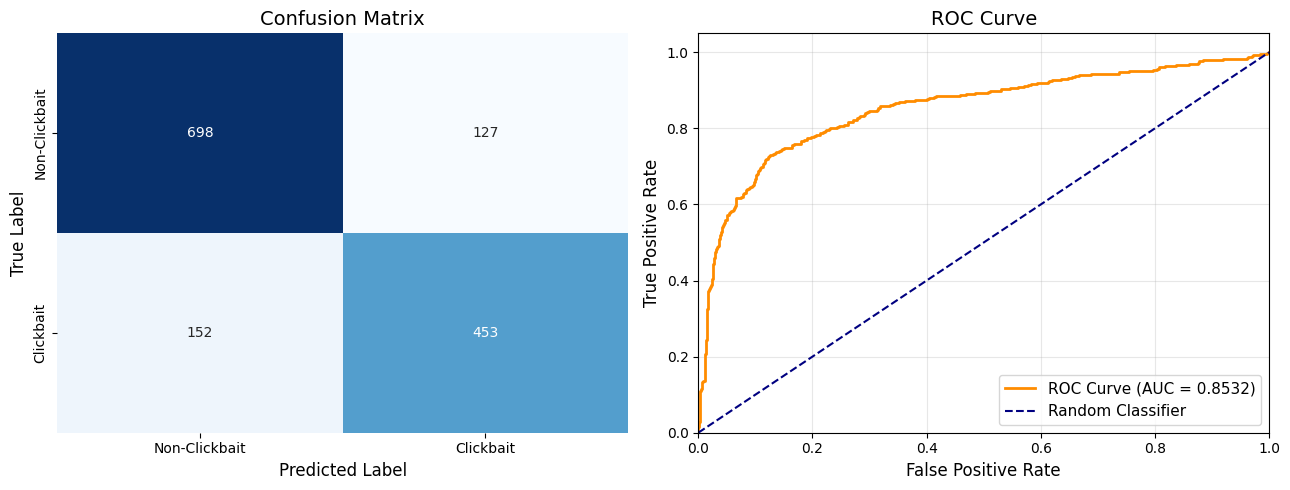


ROC AUC Score: 0.8532
Plots saved to /kaggle/working/vit_distilbert_evaluation_plots.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

def get_predictions_with_probs(model, dataloader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    print("Generating predictions on Test Set...")
    with torch.no_grad():
        for batch in dataloader:
            ids     = batch['ids'].to(device)
            mask    = batch['mask'].to(device)
            images  = batch['image'].to(device)
            targets = batch['targets'].to(device)
            outputs = model(ids, mask, images)
            probs   = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(targets.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_prob = get_predictions_with_probs(model, test_loader, DEVICE)

# ================================
# Classification Report
# ================================
print("\n" + "="*35)
print("         MODEL EVALUATION")
print("="*35)
print(classification_report(y_true, y_pred, target_names=['Non-Clickbait (0)', 'Clickbait (1)']))

print(f"Summary Metrics:")
print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")

# ================================
# Confusion Matrix + ROC Curve
# ================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'],
            ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/vit_distilbert_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nROC AUC Score: {roc_auc:.4f}")
print("Plots saved to /kaggle/working/vit_distilbert_evaluation_plots.png")
